In [1]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Thejas\DocTrace_AI\ml-training
['.gitkeep', '.ipynb_checkpoints', '01-phash-experiments.ipynb', '02-pdf-coordinates.ipynb', 'img1.jpg', 'img2.jpg', 'img3.jpg', 'other.pdf', 'requirements.txt', 'sample.pdf', 'sample2.pdf', 'Untitled.ipynb']


In [3]:
import pdfplumber
import imagehash
from PIL import ImageDraw

def fingerprint_pdf(path, dpi=150):
    """PDF -> masked skeleton -> perceptual hash (the template fingerprint)."""
    scale = dpi / 72
    with pdfplumber.open(path) as pdf:
        page = pdf.pages[0]
        words = page.extract_words()
        pil = page.to_image(resolution=dpi).original.copy()
    draw = ImageDraw.Draw(pil)
    for w in words:
        draw.rectangle(
            [w['x0']*scale, w['top']*scale, w['x1']*scale, w['bottom']*scale],
            fill="white"
        )
    return imagehash.phash(pil), pil

In [4]:
fp1, skel1 = fingerprint_pdf("sample.pdf")
fp2, skel2 = fingerprint_pdf("sample2.pdf")
fp3, skel3 = fingerprint_pdf("other.pdf")

print("sample  :", fp1)
print("sample2 :", fp2)
print("other   :", fp3)
print()
print("SAME template (sample vs sample2):", fp1 - fp2)
print("DIFF template (sample vs other)  :", fp1 - fp3)

sample  : fe7e7e818181817c
sample2 : ee4e1b91b1a1e4e4
other   : ae2b2b2bd0d4d4d4

SAME template (sample vs sample2): 18
DIFF template (sample vs other)  : 28


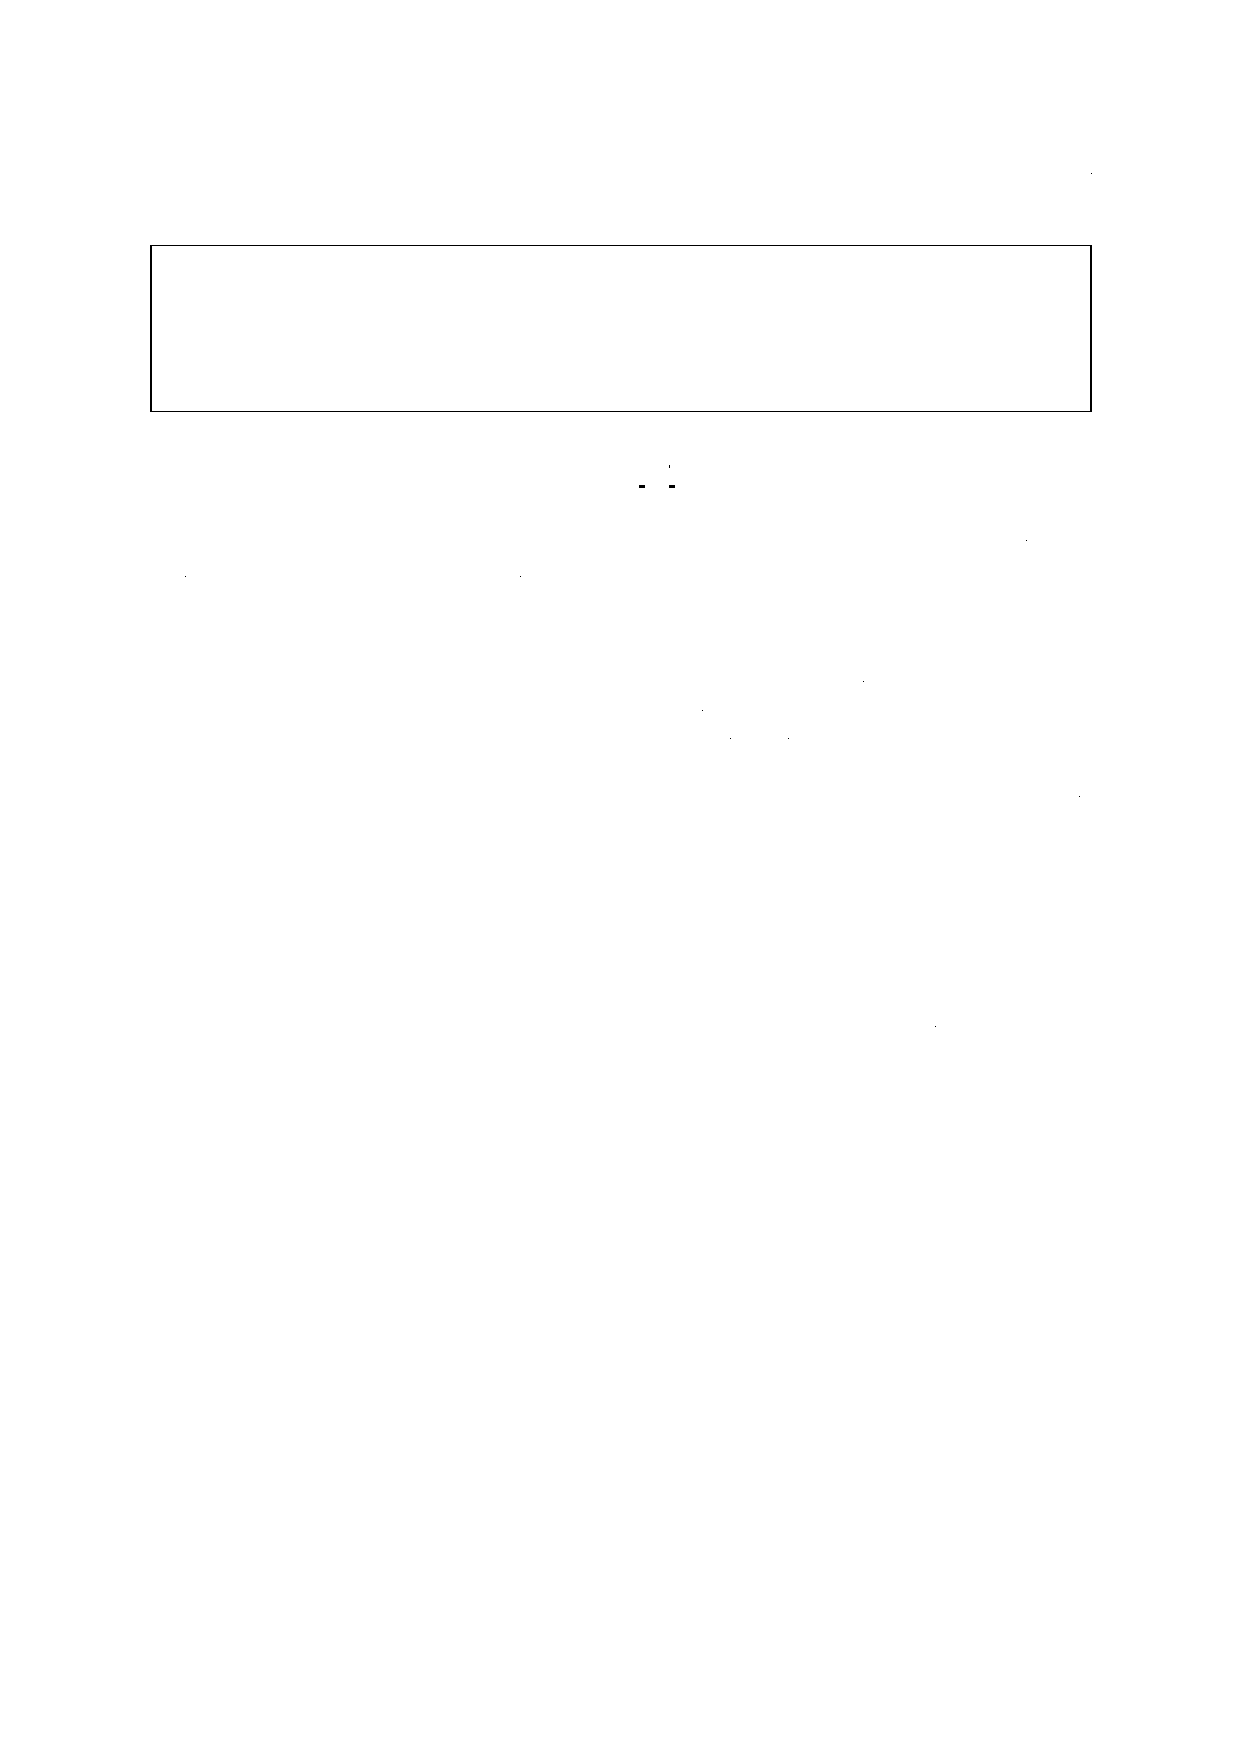

In [5]:
skel2   # sample2's skeleton — should look like yesterday's twin


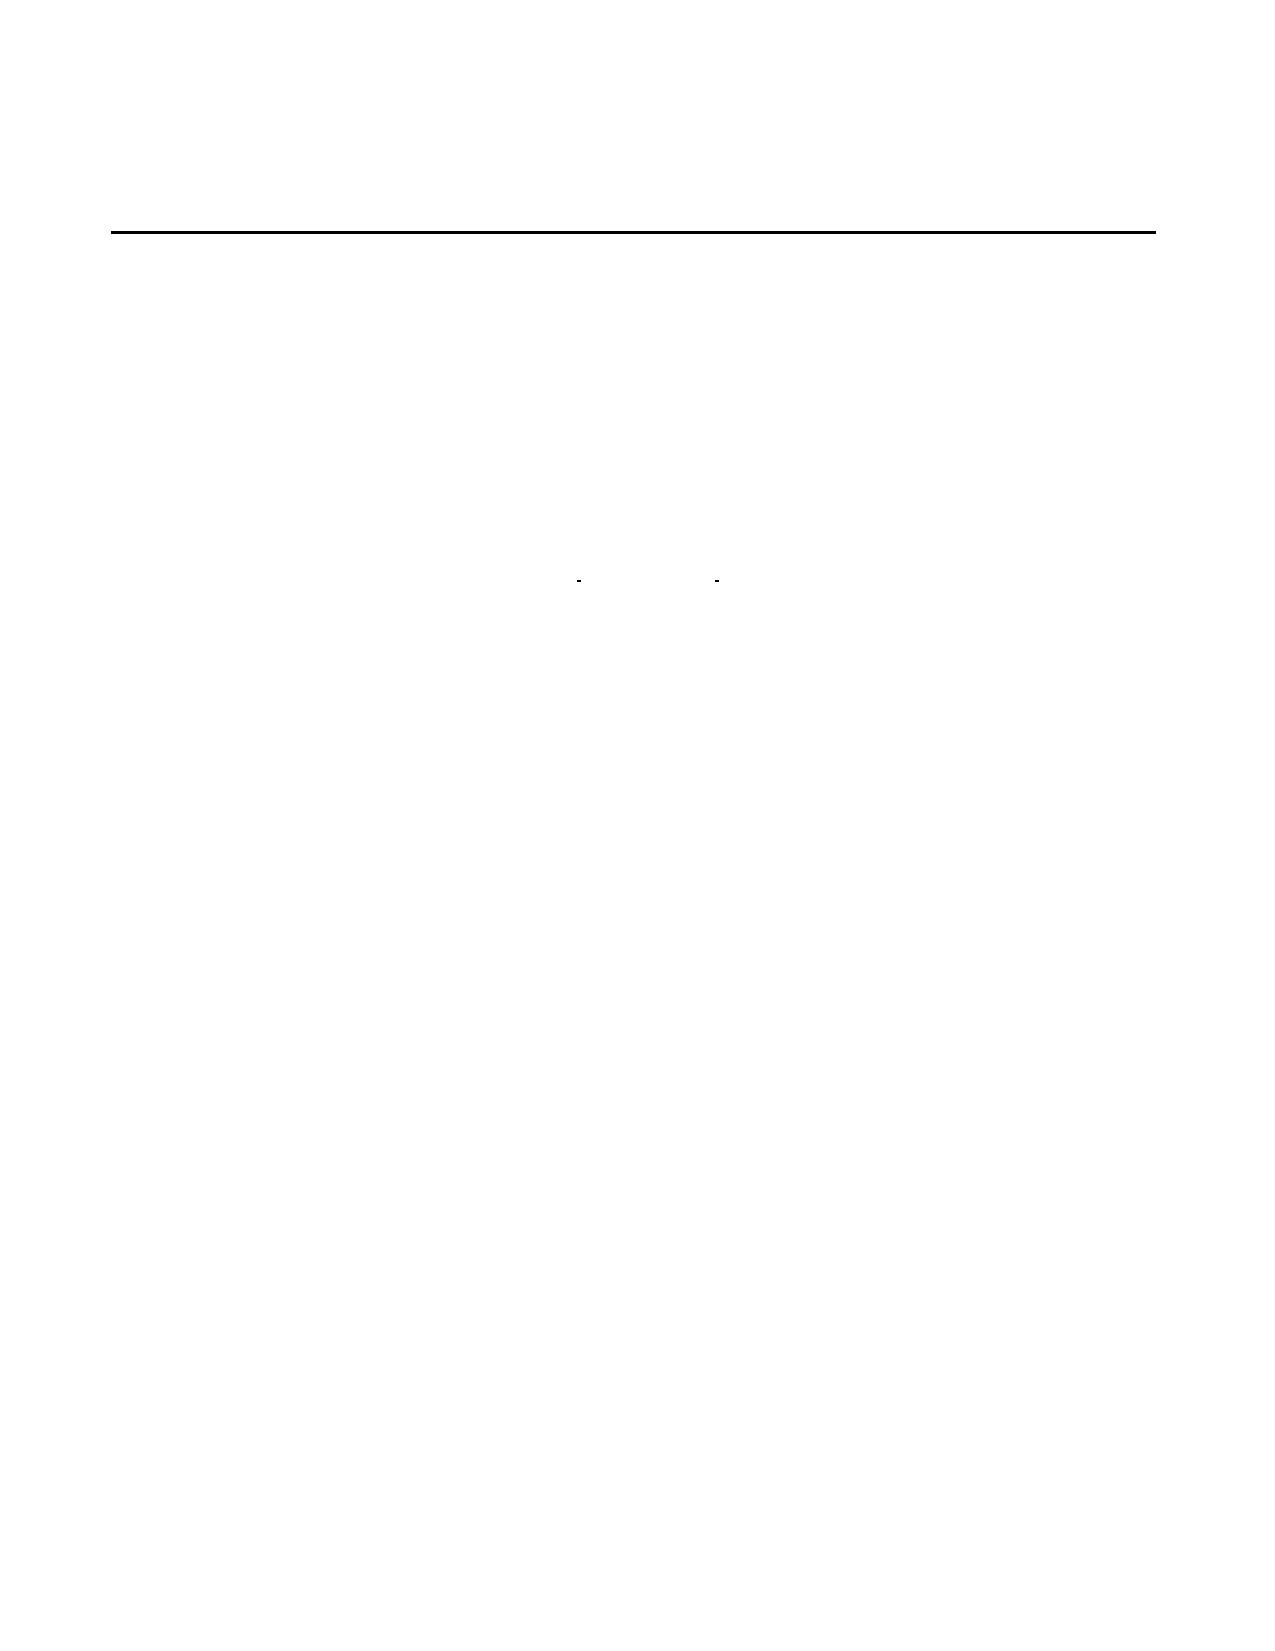

In [6]:
skel3   # other.pdf's skeleton — should look nothing like it

In [7]:
fp_a, skel_a = fingerprint_pdf("IDK.pdf")    # BHAT invoice A
fp_b, skel_b = fingerprint_pdf("IDK2.pdf")   # BHAT invoice B (same template!)
fp_s, skel_s = fingerprint_pdf("sample.pdf") # original BHAT sample
fp_o, skel_o = fingerprint_pdf("other.pdf")  # different document

print("IDK    :", fp_a)
print("IDK2   :", fp_b)
print("sample :", fp_s)
print("other  :", fp_o)
print()
print("SAME template (IDK vs IDK2)  :", fp_a - fp_b, "  <- expecting 0-8")
print("SAME template (IDK vs sample):", fp_a - fp_s, "  <- also same app template?")
print("DIFF template (IDK vs other) :", fp_a - fp_o, "  <- expecting 15+")


IDK    : ee6e9d84c495916a
IDK2   : ea6a3a369684cdc9
sample : fe7e7e818181817c
other  : ae2b2b2bd0d4d4d4

SAME template (IDK vs IDK2)  : 24   <- expecting 0-8
SAME template (IDK vs sample): 18   <- also same app template?
DIFF template (IDK vs other) : 28   <- expecting 15+


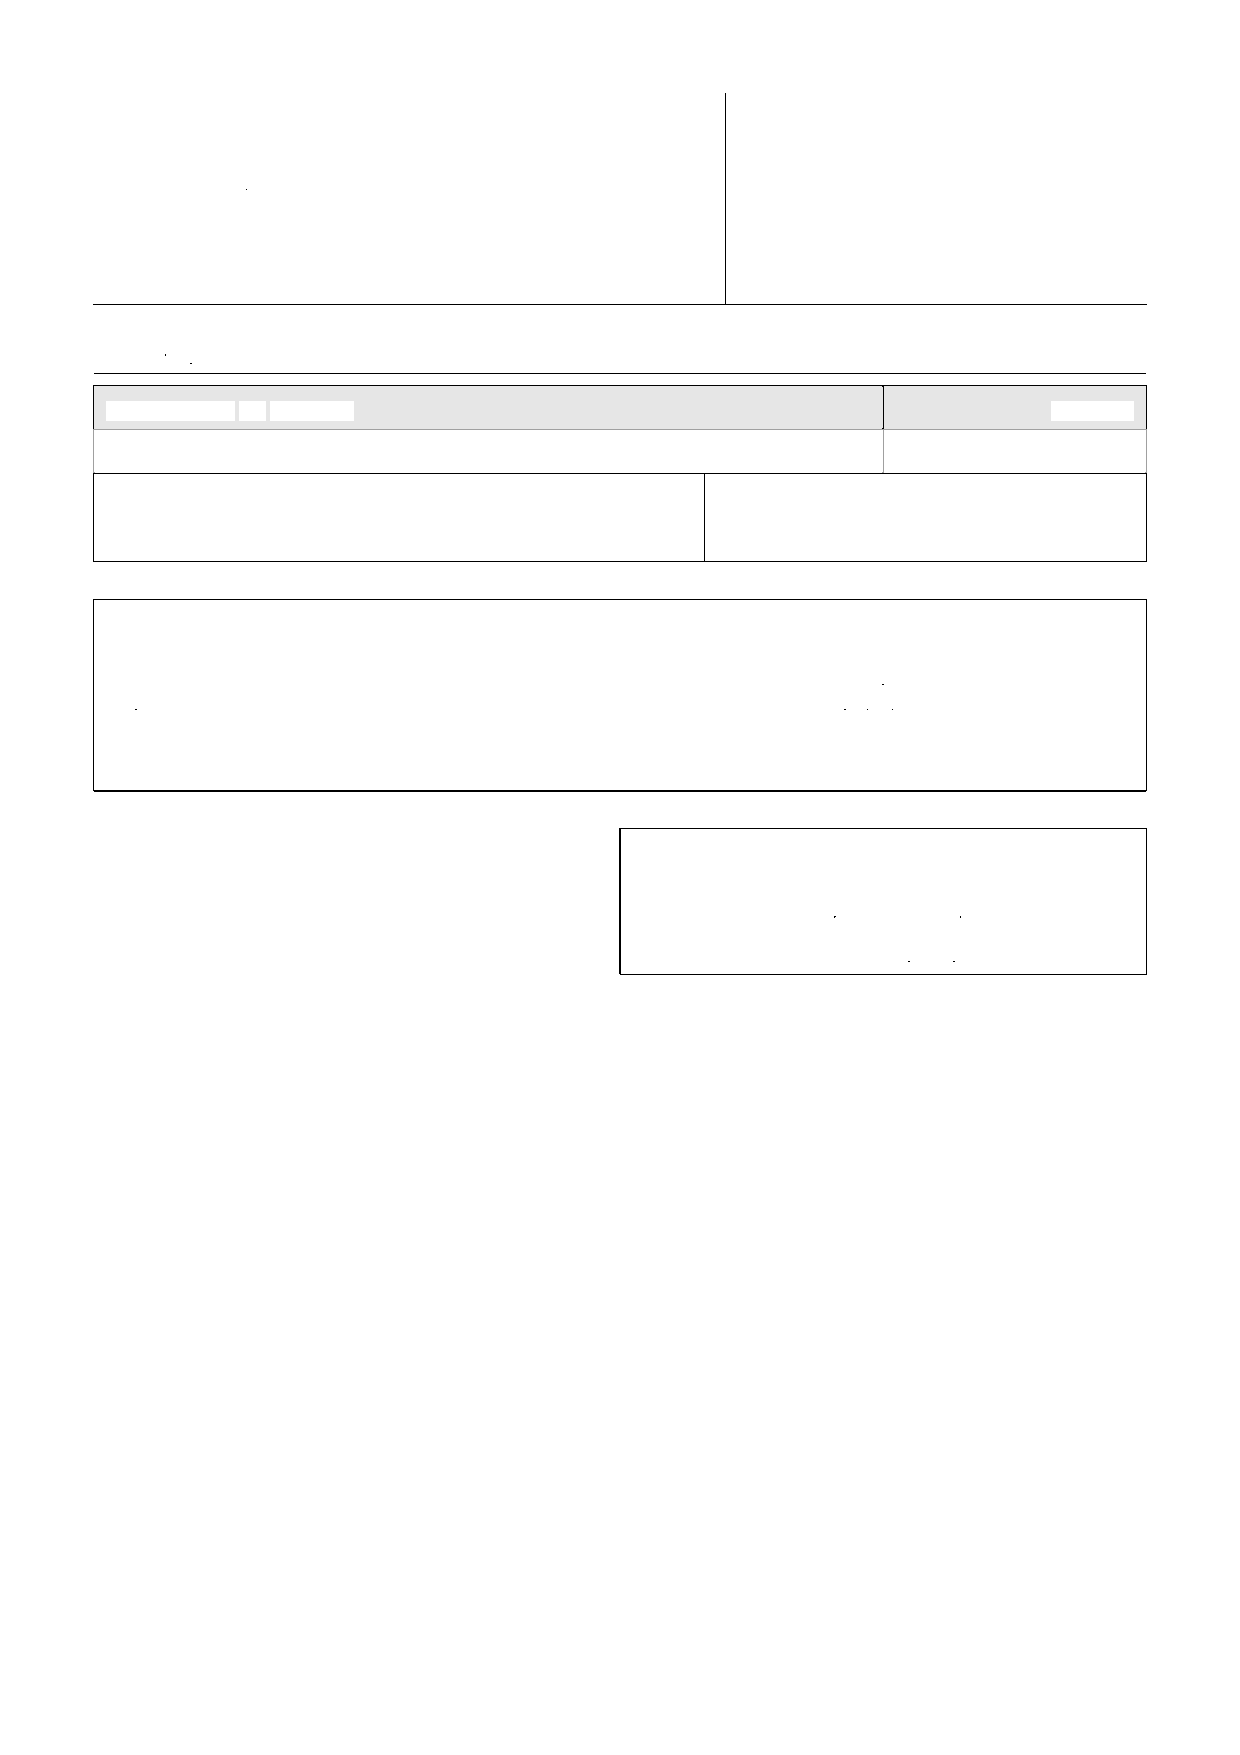

In [8]:
skel_a   # IDK's skeleton


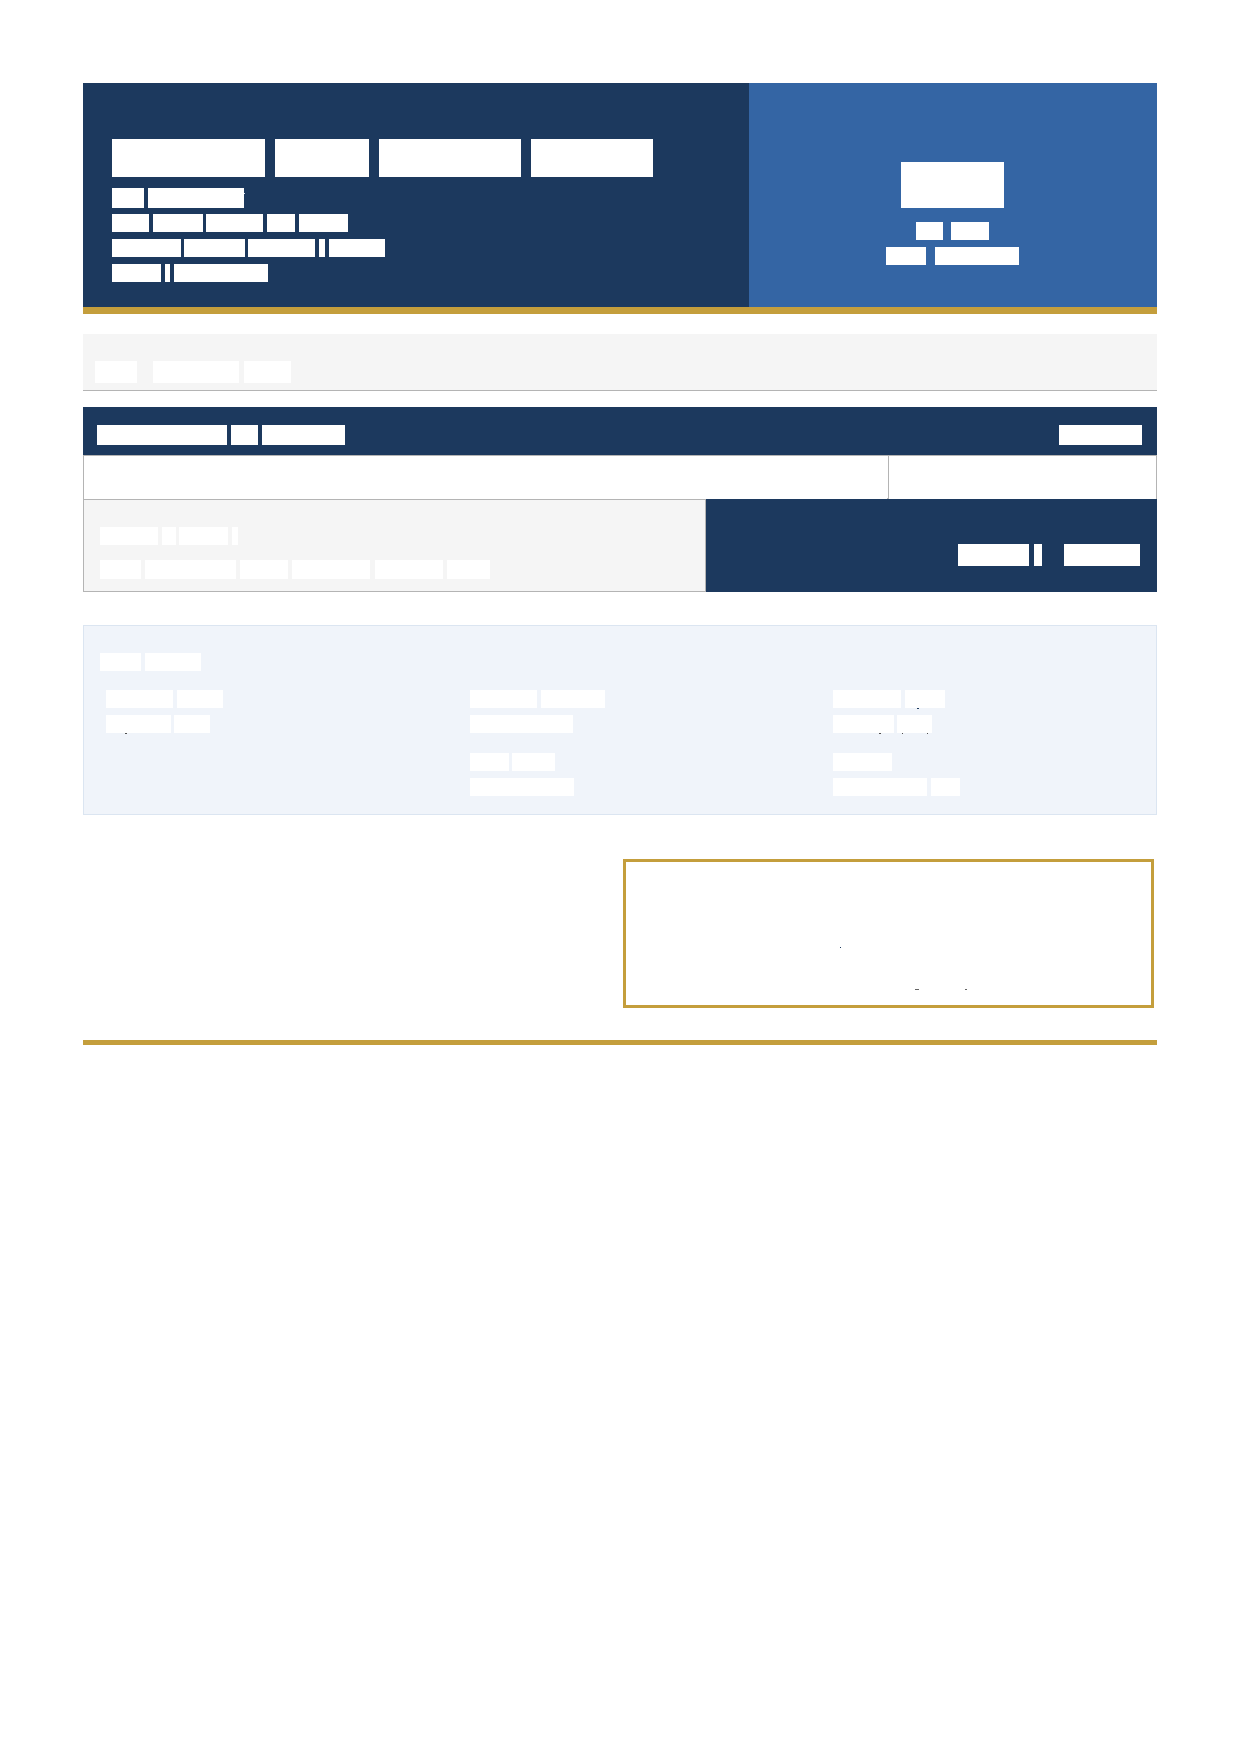

In [9]:
skel_b   # IDK2's skeleton

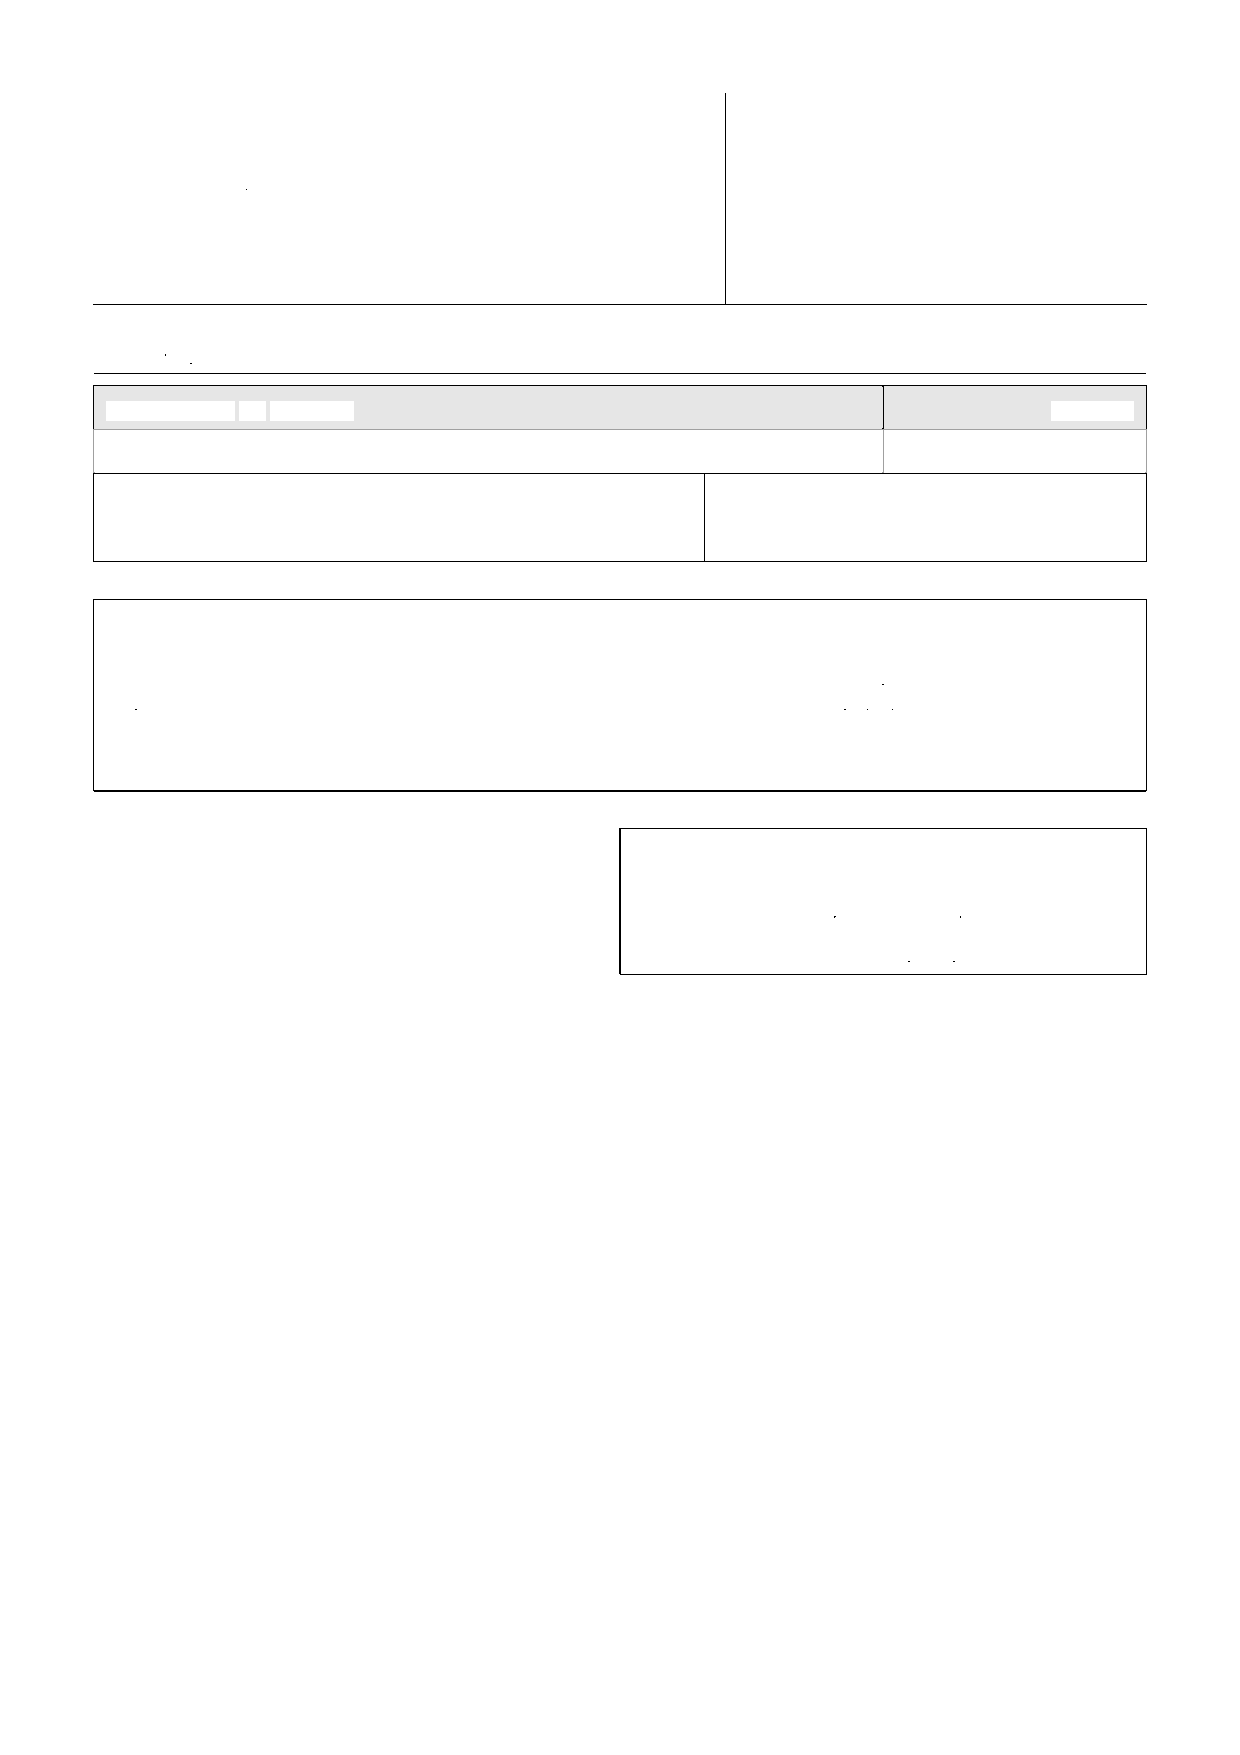

In [10]:
skel_a   # then skel_b in the next cell — are they mostly blank?


In [11]:
for name in ["IDK.pdf", "IDK2.pdf"]:
    with pdfplumber.open(name) as pdf:
        p = pdf.pages[0]
        print(name, "| words:", len(p.extract_words()),
              "| lines:", len(p.lines), "| rects:", len(p.rects),
              "| images:", len(p.images))

IDK.pdf | words: 76 | lines: 4 | rects: 10 | images: 0
IDK2.pdf | words: 71 | lines: 1 | rects: 17 | images: 0


In [12]:
fpA, sA = fingerprint_pdf_v2("IDK.pdf")
fpB, sB = fingerprint_pdf_v2("IDK2.pdf")
fpO, sO = fingerprint_pdf_v2("other.pdf")

print("SAME (IDK vs IDK2) :", fpA - fpB)
print("DIFF (IDK vs other):", fpA - fpO)

NameError: name 'fingerprint_pdf_v2' is not defined

In [13]:
def fingerprint_pdf_v2(path, dpi=150):
    """PDF -> BLOCK MAP (words as black boxes) -> perceptual hash."""
    scale = dpi / 72
    with pdfplumber.open(path) as pdf:
        page = pdf.pages[0]
        words = page.extract_words()
        pil = page.to_image(resolution=dpi).original.copy()
    draw = ImageDraw.Draw(pil)
    for w in words:
        draw.rectangle(
            [w['x0']*scale, w['top']*scale, w['x1']*scale, w['bottom']*scale],
            fill="black"
        )
    return imagehash.phash(pil), pil

In [14]:
fpA, sA = fingerprint_pdf_v2("IDK.pdf")
fpB, sB = fingerprint_pdf_v2("IDK2.pdf")
fpO, sO = fingerprint_pdf_v2("other.pdf")

print("SAME (IDK vs IDK2) :", fpA - fpB)
print("DIFF (IDK vs other):", fpA - fpO)

SAME (IDK vs IDK2) : 16
DIFF (IDK vs other): 28


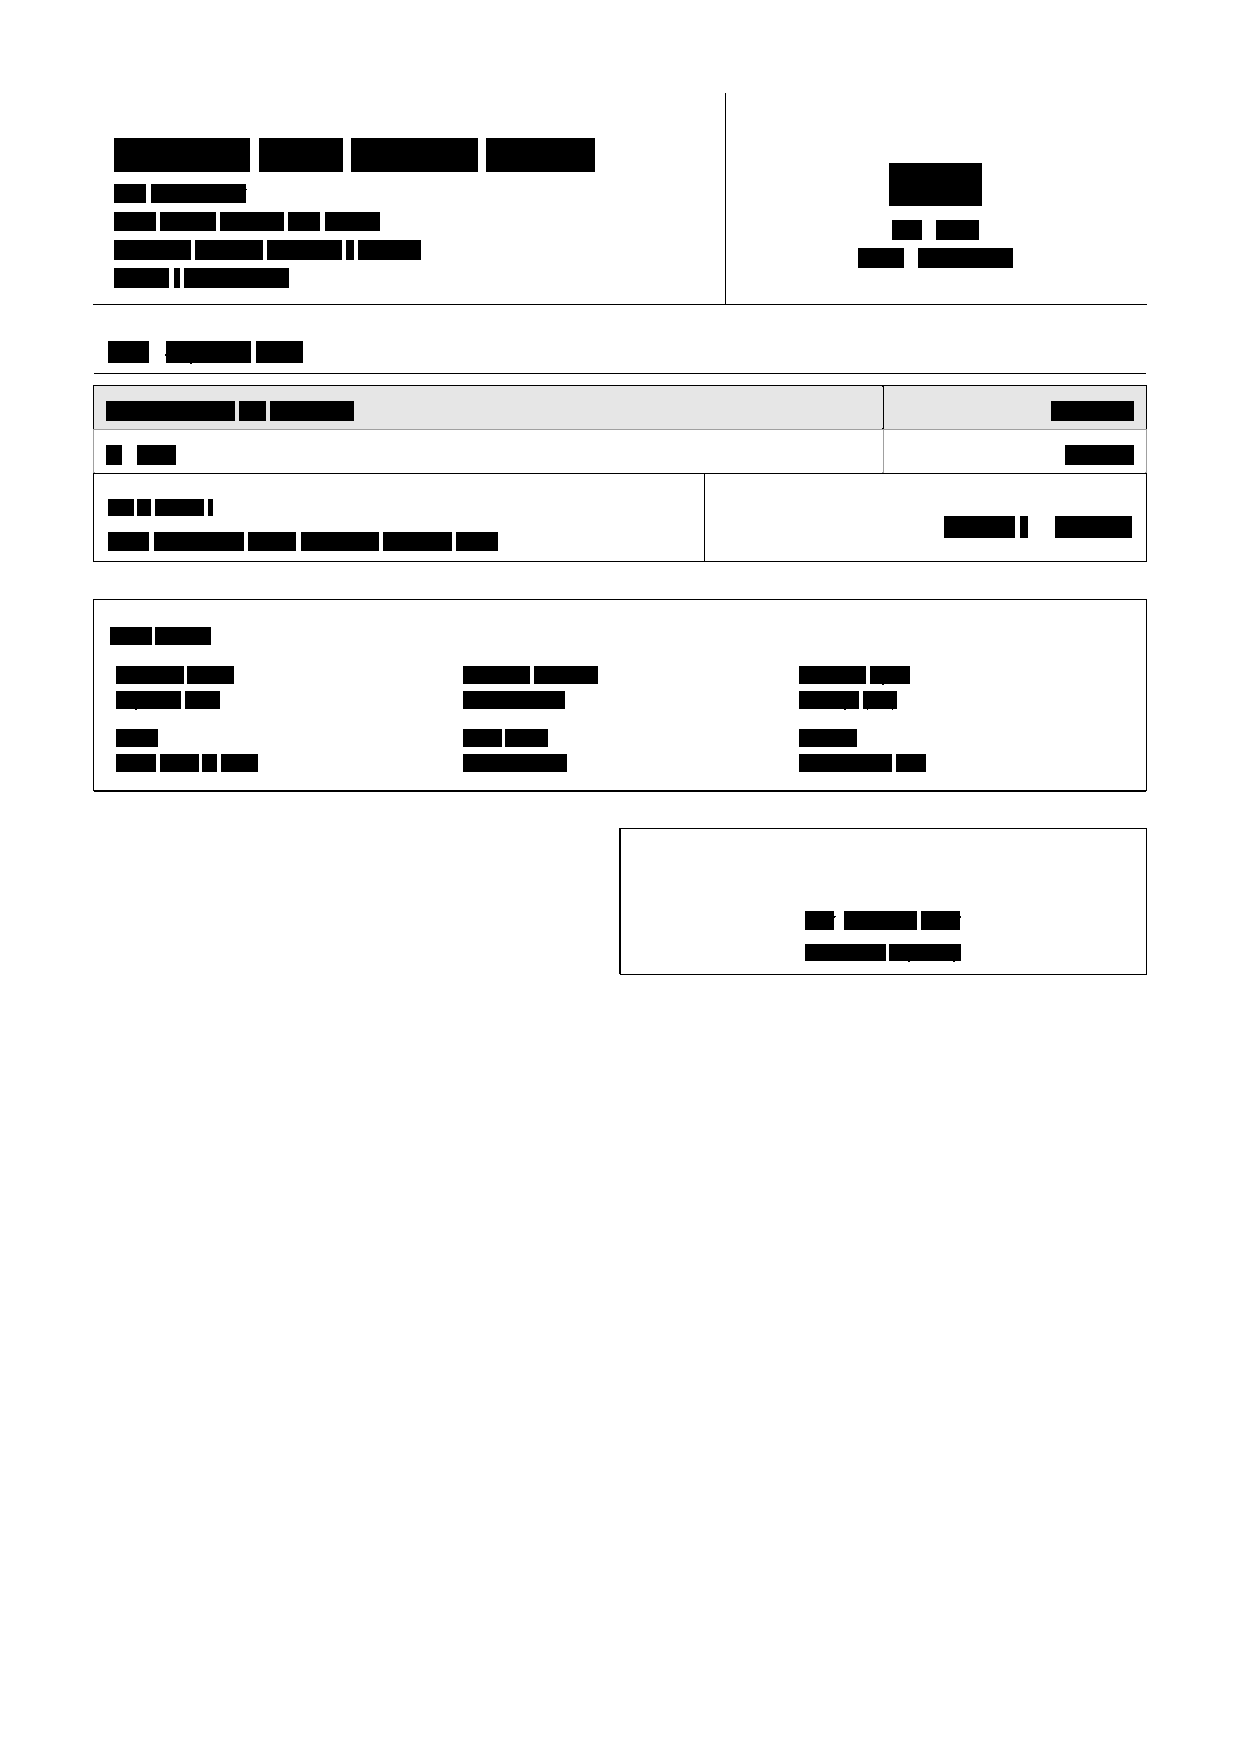

In [15]:
sA   # IDK's block map


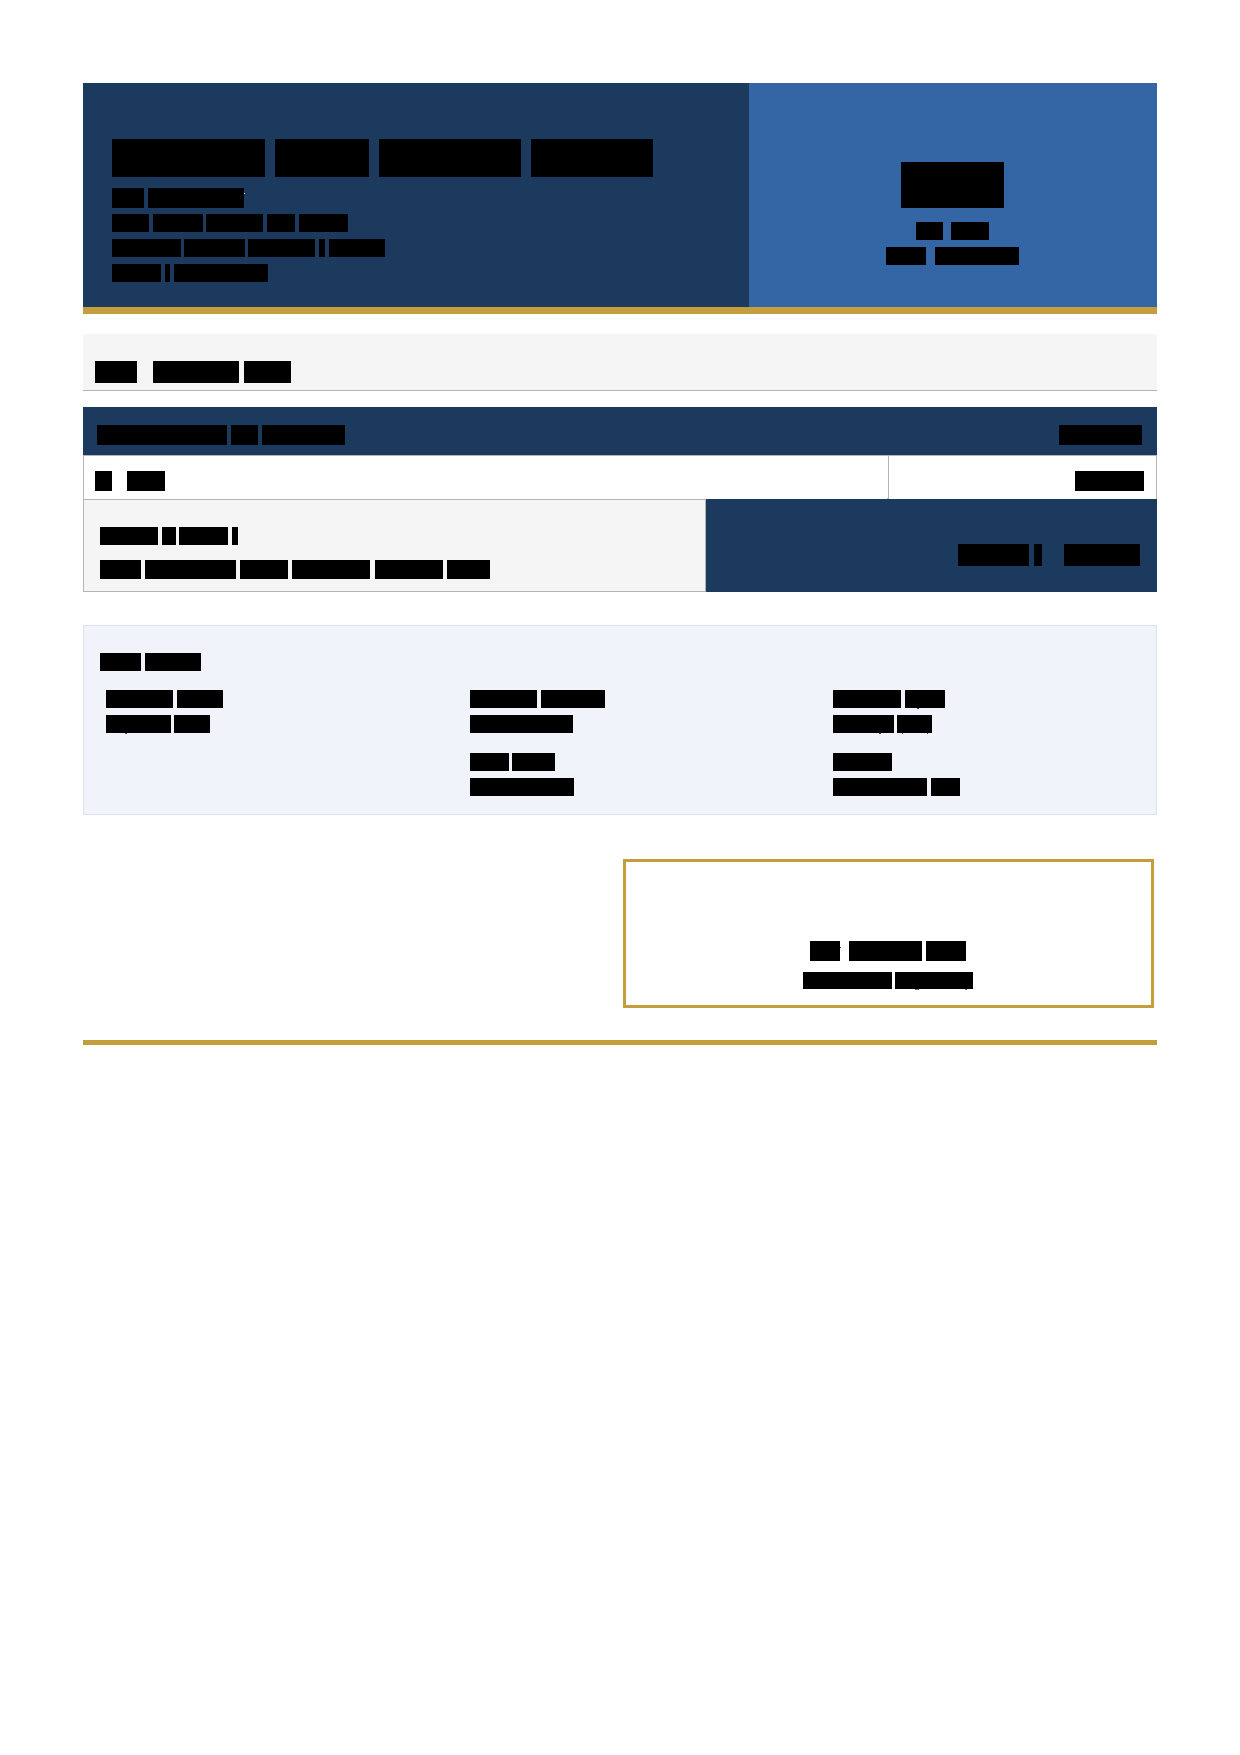

In [16]:
sB   # IDK2's block map

In [17]:
fpA, sA = fingerprint_pdf_v2("t1.pdf")
fpB, sB = fingerprint_pdf_v2("t2.pdf")
print("TRUE same template:", fpA - fpB)

TRUE same template: 12


In [18]:
fpA, sA = fingerprint_pdf_v2("t1.pdf")
fpB, sB = fingerprint_pdf_v2("t2.pdf")
print("TRUE same template:", fpA - fpB)

TRUE same template: 0
